# 🌈 Colored Shapes Autoencoder Project

Is project mein Autoencoder ko step by step samjhenge.

Autoencoder ka kaam:

- Image ko input lena
- Important features compress karna
- Image ko dobara reconstruct karna
- Noisy image ko clean karna

Is project mein labels use nahi honge.

## 1. Libraries Import Karna

Hum sirf essential libraries use karenge.

In [1]:
# Deep Learning model ke liye TensorFlow import kar rahe hain
import tensorflow as tf

# Arrays handle karne ke liye NumPy import kar rahe hain
import numpy as np

# Images aur graphs show karne ke liye Matplotlib import kar rahe hain
import matplotlib.pyplot as plt

## 2. Important Values

### `image_size = (64, 64)`
Har image ko 64 × 64 size mein load kiya jayega.

### `batch_size = 32`
Model ek time par 32 images process karega.

In [2]:
# Image ka fixed size define kar rahe hain
image_size = (64, 64)

# Ek batch mein 32 images rakh rahe hain
batch_size = 32

## 3. Dataset Paths

In [3]:
# Main dataset folder ka path
dataset_path = "colored_shapes_autoencoder_dataset"

# Training folder ka path
train_path = dataset_path + "/train"

# Validation folder ka path
validation_path = dataset_path + "/validation"

# Test folder ka path
test_path = dataset_path + "/test"

## 4. Image Loading Function

Autoencoder mein labels ki zarurat nahi hoti.

Is liye hum sirf images load karenge.

In [4]:
# Image file ko read aur prepare karne ka function
def load_image(image_path):

    # Image file read kar rahe hain
    image = tf.io.read_file(image_path)

    # Image ko RGB format mein decode kar rahe hain
    image = tf.image.decode_png(image, channels=3)

    # Image ko 64 × 64 size mein resize kar rahe hain
    image = tf.image.resize(image, image_size)

    # Pixel values ko 0 se 1 range mein convert kar rahe hain
    image = image / 255.0

    # Autoencoder mein input aur target dono same image hoti hain
    return image, image

## 5. Training Files Load Karna

In [5]:
# Training folder ki tamam PNG files collect kar rahe hain
train_files = tf.data.Dataset.list_files(
    train_path + "/*.png",
    shuffle=True,
    seed=42
)

## 6. Training Dataset Prepare Karna

In [6]:
# Har file par load_image function apply kar rahe hain
train_ds = train_files.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)


In [7]:
# Training images ko batches mein divide kar rahe hain
train_ds = train_ds.batch(batch_size)

# Next batch background mein ready kar rahe hain
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

## 7. Validation Dataset Prepare Karna

In [8]:
# Validation image files collect kar rahe hain
validation_files = tf.data.Dataset.list_files(
    validation_path + "/*.png",
    shuffle=False
)

In [9]:
# Validation images load kar rahe hain
validation_ds = validation_files.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [10]:
# Validation batches create kar rahe hain
validation_ds = validation_ds.batch(batch_size)

# Validation data ko faster bana rahe hain
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)

## 8. Test Dataset Prepare Karna

In [11]:
# Test image files collect kar rahe hain
test_files = tf.data.Dataset.list_files(
    test_path + "/*.png",
    shuffle=False
)

In [12]:
# Test images load kar rahe hain
test_ds = test_files.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [13]:
# Test batches create kar rahe hain
test_ds = test_ds.batch(batch_size)

# Test data ko faster bana rahe hain
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

## 9. Sample Images Show Karna

In [14]:
# Training dataset ka ek batch le rahe hain
for images, targets in train_ds.take(1):
    print("Batch Shape:", images.shape)
    print("Single Image Shape:", images[0].shape)

Batch Shape: (32, 64, 64, 3)
Single Image Shape: (64, 64, 3)


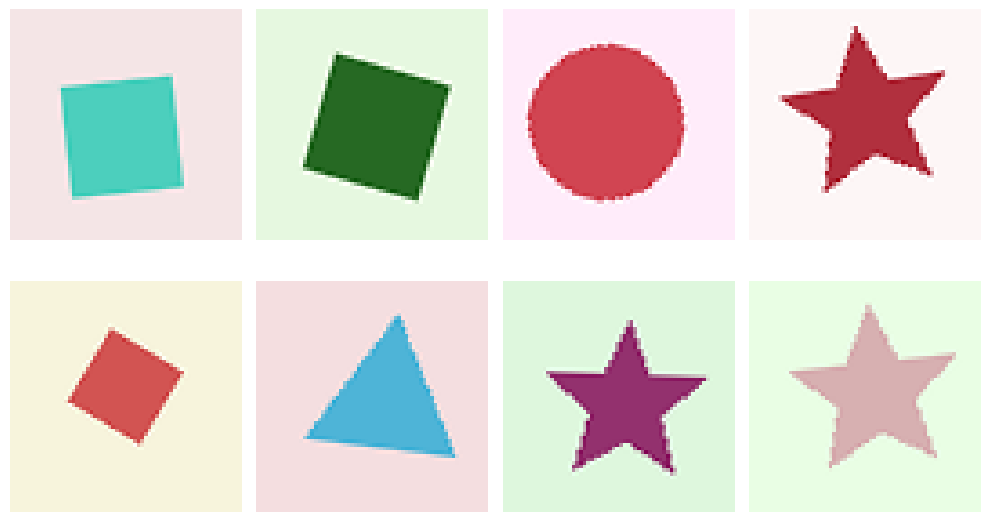

In [15]:
# Sample images show karne ke liye figure create kar rahe hain
plt.figure(figsize=(10, 6))

# Pehli 8 images show kar rahe hain
for index in range(8):

    # 2 rows aur 4 columns
    plt.subplot(2, 4, index + 1)

    # RGB image show kar rahe hain
    plt.imshow(images[index])

    # Axis hide kar rahe hain
    plt.axis("off")

plt.tight_layout()
plt.show()

# Encoder Part

Encoder image ko chhoti compressed representation mein convert karta hai.

## 10. Input Layer

In [16]:
# Autoencoder ki input image define kar rahe hain
input_image = tf.keras.Input(
    shape=(64, 64, 3)
)

## 11. First Encoder Layer

`32 filters` basic features learn karenge.

`strides=2` image size ko half karega.

In [17]:
# Pehli encoder convolution layer
x = tf.keras.layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=2,
    padding="same",
    activation="relu"
)(input_image)   #Is Conv2D layer ko input_image ke upar apply karo. layer(input)

## 12. Second Encoder Layer

`64 filters` zyada detailed features seekhenge.

In [18]:
# Doosri encoder convolution layer
x = tf.keras.layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    strides=2,
    padding="same",
    activation="relu"
)(x)

## 13. Compressed Representation

Is stage par image ka size kam ho chuka hota hai.

Yahi compressed features ya latent representation hoti hai.

In [19]:
# Compressed feature representation
encoded = tf.keras.layers.Conv2D(
    filters=128,
    kernel_size=(3, 3),
    strides=2,
    padding="same",
    activation="relu",
    name="compressed_features"
)(x)

# Decoder Part

Decoder compressed features se image dobara banata hai.

## 14. First Decoder Layer

`Conv2DTranspose` image size ko increase karta hai.

In [20]:
# Pehli decoder layer
x = tf.keras.layers.Conv2DTranspose(
    filters=64,
    kernel_size=(3, 3),
    strides=2,
    padding="same",
    activation="relu"
)(encoded)

## 15. Second Decoder Layer

In [21]:
# Doosri decoder layer
x = tf.keras.layers.Conv2DTranspose(
    filters=32,
    kernel_size=(3, 3),
    strides=2,
    padding="same",
    activation="relu"
)(x)

## 16. Output Layer

Output image ke 3 RGB channels honge.

`sigmoid` output pixels ko 0 se 1 range mein rakhega.

In [22]:
# Reconstructed image create kar rahe hain
decoded = tf.keras.layers.Conv2DTranspose(
    filters=3,
    kernel_size=(3, 3),
    strides=2,
    padding="same",
    activation="sigmoid"
)(x)

## 17. Complete Autoencoder Model

In [23]:
# Input aur output ko connect karke model bana rahe hain
autoencoder = tf.keras.Model(
    inputs=input_image,
    outputs=decoded
)

In [24]:
# Model architecture show kar rahe hain
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ compressed_features (Conv2D)         │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 16, 16, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 64, 64, 3)           │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 186,371 (728.01 KB)

 Trainable params: 186,371 (728.01 KB)

 Non-trainable params: 0 (0.00 B)

## 18. Model Compile Karna

### `optimizer="adam"`
Weights update karta hai.

### `loss="mse"`
Original aur reconstructed image ke pixels ka difference calculate karta hai.

In [25]:
# Autoencoder ko training ke liye ready kar rahe hain
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

## 19. Autoencoder Train Karna

Autoencoder mein input aur target same image hoti hai.

In [26]:
# Autoencoder ko train kar rahe hain
history = autoencoder.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15
)

Epoch 1/15


D:\Anaconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.1084 - val_loss: 0.0636
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0519 - val_loss: 0.0413
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0320 - val_loss: 0.0263
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0228 - val_loss: 0.0220
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0197 - val_loss: 0.0185
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.0167 - val_loss: 0.0158
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0145 - val_loss: 0.0150
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0137 - val_loss: 0.0131
Epoch 9/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0126 - val_loss: 0.0125
Epoch 10/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0121 - val_loss: 0.0119
Epoch 11/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0115 - val_loss: 0.0116
Epoch 12/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0110 - val_

## 20. Loss Graph

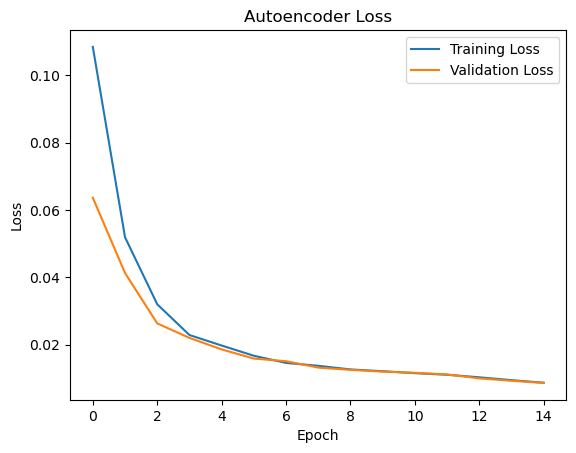

In [27]:
# Training loss show kar rahe hain
plt.plot(history.history["loss"], label="Training Loss")

# Validation loss show kar rahe hain
plt.plot(history.history["val_loss"], label="Validation Loss")

# Graph details
plt.title("Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 21. Test Loss Check Karna

In [28]:
# Test dataset par reconstruction loss check kar rahe hain
test_loss = autoencoder.evaluate(test_ds)

# Final test loss print kar rahe hain
print("Test Reconstruction Loss:", test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0086
Test Reconstruction Loss: 0.008572163060307503


## 22. Test Images Predict Karna

In [29]:
# Test dataset ka ek batch le rahe hain
for test_images, test_targets in test_ds.take(1):

    # Images reconstruct kar rahe hain
    reconstructed_images = autoencoder.predict(
        test_images,
        verbose=0
    )

## 23. Original aur Reconstructed Images Compare Karna

In [30]:
# 8 original aur reconstructed images show karenge
total_images = 8

# Figure create kar rahe hain
plt.figure(figsize=(16, 4))

<Figure size 1600x400 with 0 Axes>

<Figure size 1600x400 with 0 Axes>

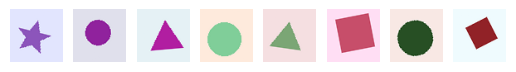

In [31]:
# Original images show kar rahe hain
for index in range(total_images):

    plt.subplot(2, total_images, index + 1)

    plt.imshow(test_images[index])

    # plt.title("Original")

    plt.axis("off")

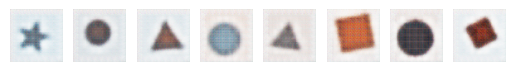

In [32]:
# Reconstructed images show kar rahe hain
for index in range(total_images):

    plt.subplot(2, total_images, index + 1 + total_images)

    plt.imshow(reconstructed_images[index])

    # plt.title("Reconstructed")

    plt.axis("off")

In [33]:
# Layout adjust karke images show kar rahe hain
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

# Denoising Autoencoder

Ab hum images mein artificial noise add karenge.

Model noisy image se clean image reconstruct karega.

## 24. Noise Add Karne Ka Function

In [34]:
# Image mein random noise add karne ka function
def add_noise(image, target):

    # Random normal noise create kar rahe hain
    noise = tf.random.normal(
        shape=tf.shape(image),
        mean=0.0,
        stddev=0.15
    )

    # Original image mein noise add kar rahe hain
    noisy_image = image + noise

    # Pixel values ko 0 se 1 range mein rakh rahe hain
    noisy_image = tf.clip_by_value(
        noisy_image,
        0.0,
        1.0
    )

    # Input noisy image aur target clean image hogi
    return noisy_image, image

## 25. Noisy Training Dataset

In [35]:
# Training images mein noise add kar rahe hain
noisy_train_ds = train_ds.map(
    add_noise,
    num_parallel_calls=tf.data.AUTOTUNE
)

## 26. Noisy Validation Dataset

In [36]:
# Validation images mein noise add kar rahe hain
noisy_validation_ds = validation_ds.map(
    add_noise,
    num_parallel_calls=tf.data.AUTOTUNE
)

## 27. Denoising Model Train Karna

Same model ko noisy input aur clean target par train kar rahe hain.

In [37]:
# Denoising training start kar rahe hain
denoising_history = autoencoder.fit(
    noisy_train_ds,
    validation_data=noisy_validation_ds,
    epochs=10
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0090 - val_loss: 0.0082
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0080 - val_loss: 0.0076
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0075 - val_loss: 0.0075
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0074 - val_loss: 0.0074
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0074 - val_loss: 0.0077
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0072 - val_loss: 0.0071
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0069 - val_loss: 0.0073
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0070 - val_loss: 0.0071
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0067 - val_loss: 0.0067
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0066 - val_loss: 0.0065


## 28. Noisy Test Images Prepare Karna

In [38]:
# Test batch le rahe hain
for clean_images, clean_targets in test_ds.take(1):

    # Test images mein noise add kar rahe hain
    noisy_images, clean_images = add_noise(
        clean_images,
        clean_targets
    )

## 29. Noisy Images Ko Clean Karna

In [39]:
# Noisy images se clean output predict kar rahe hain
cleaned_images = autoencoder.predict(
    noisy_images,
    verbose=0
)

## 30. Clean, Noisy aur Reconstructed Images

In [40]:
# 6 images compare karenge
total_images = 6

# Figure create kar rahe hain
plt.figure(figsize=(15, 7))

<Figure size 1500x700 with 0 Axes>

<Figure size 1500x700 with 0 Axes>

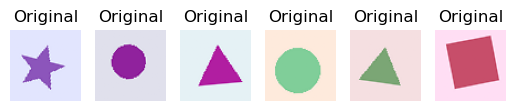

In [41]:
# Original clean images
for index in range(total_images):

    plt.subplot(3, total_images, index + 1)

    plt.imshow(clean_images[index])

    plt.title("Original")

    plt.axis("off")

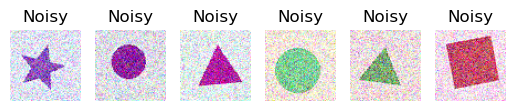

In [42]:
# Noisy images
for index in range(total_images):

    plt.subplot(3, total_images, index + 1 + total_images)

    plt.imshow(noisy_images[index])

    plt.title("Noisy")

    plt.axis("off")

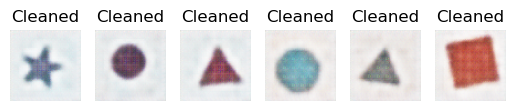

In [43]:
# Autoencoder se cleaned images
for index in range(total_images):

    plt.subplot(3, total_images, index + 1 + (2 * total_images))

    plt.imshow(cleaned_images[index])

    plt.title("Cleaned")

    plt.axis("off")

In [44]:
# Layout adjust karke result show kar rahe hain
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

#  Project Complete

Is notebook mein humne:

1. Labels ke baghair images load ki
2. Encoder create kiya
3. Compressed features banaye
4. Decoder create kiya
5. Images reconstruct ki
6. Reconstruction loss check kiya
7. Noise add ki
8. Noisy images clean ki


### Important Difference

CNN classification karta hai.

Autoencoder image ko reconstruct karta hai.